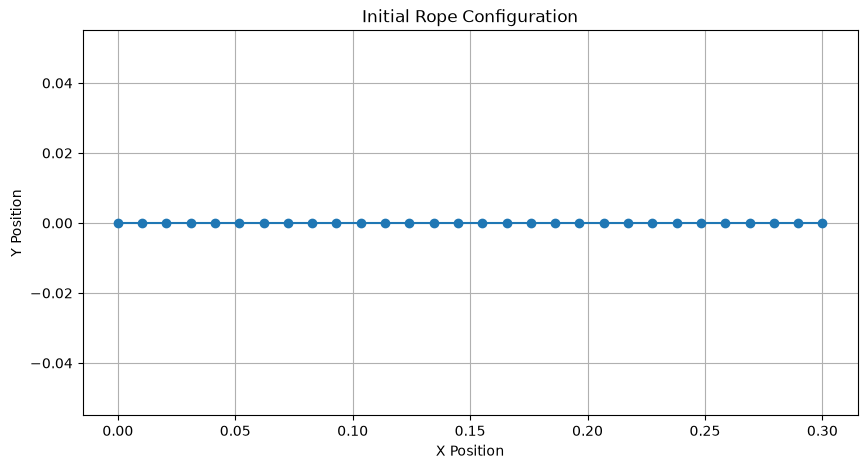

In [2]:
# Random input data applied to end of rope 
import numpy as np

u = [[1,2]]

# Current rope config (x1,y1, vx1, vy1, x2, y2, vx2, vy2....)
n_nodes=30

base_length=0.30
base_radius=0.003
youngs_modulus=1e6
damping=2.0
dt=5e-5
control_dt=0.01

N = 30 

# Rope fixed at 0,0, along x-axis, with 30 nodes, each with 4 state variables (x, y, vx, vy)`
x0 = np.zeros((N, 4))
for i in range(N):
    x0[i, 0] = (i * base_length) / (N - 1)  # x position
    x0[i, 1] = 0.0                         # y position
    x0[i, 2] = 0.0                         # x velocity
    x0[i, 3] = 0.0                         # y velocity

# Draw rope config using matplotlib
# Initial
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(x0[:, 0], x0[:, 1], 'o-')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Initial Rope Configuration')
plt.grid(True)
plt.show()


Initializing PyElastica RopeManipEnv ...
Rope has 30 nodes. Recorded timestep dt = 0.0100 s.
Step 1: Action (mm): [1. 2.], driven node (mm): [1. 2.]


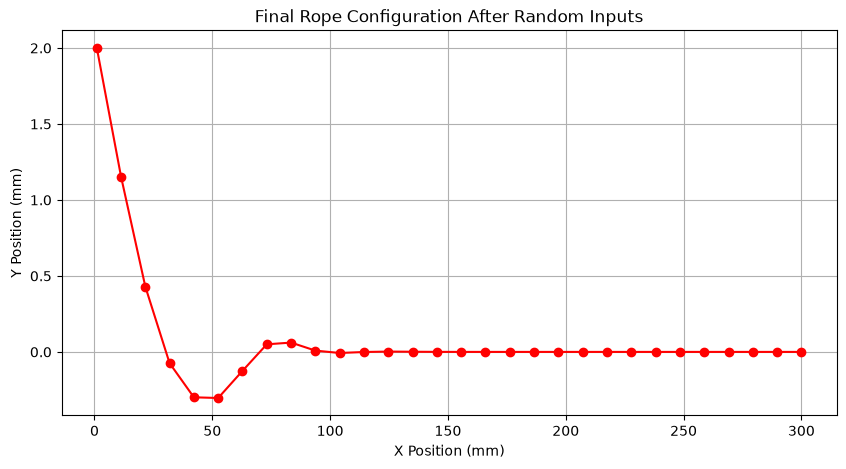

In [3]:
# Use the random input data to simulate the rope dynamics
from rope_manip_env import RopeManipEnv

# MM = 1000.0  # Conversion factor from meters to millimeters
MM = 1000.0
print("Initializing PyElastica RopeManipEnv ...")
env = RopeManipEnv(
    n_nodes=30,
    base_length=0.30,
    base_radius=0.003,
    youngs_modulus=1e6,
    damping=2.0,
    dt=5e-5,
    control_dt=0.01,
    seed=42,
)

env.reset()
num_points = env.n_nodes
DT = env.control_dt                      # one recorded timestep, in seconds
print(f"Rope has {num_points} nodes. Recorded timestep dt = {DT:.4f} s.")

# Final rope config after applying random input data.
# RopeManipEnv has no gym-style step(); drive_step(cmd_xy) moves the driven node by

# cmd_xy (metres) over one control step and returns the new positions directly.
# `u` here is treated as millimetres (matching the rest of this project's convention),
# so it's converted to metres before being passed in.
pos_before = env.get_positions(mm=True)[:, :2].copy()
vel_before = env.get_velocities(mm=True)[:, :2].copy()

for i in range(len(u)):
    action_mm = np.asarray(u[i], dtype=float)
    positions = env.drive_step(action_mm / MM)
    print(f"Step {i+1}: Action (mm): {action_mm}, driven node (mm): {positions[0, :2] * MM}")


# Plot final rope configuration
final_config = env.get_positions(mm=True)
plt.figure(figsize=(10, 5))
plt.plot(final_config[:, 0], final_config[:, 1], 'o-', color='r')
plt.xlabel('X Position (mm)')
plt.ylabel('Y Position (mm)')
plt.title('Final Rope Configuration After Random Inputs')
plt.grid(True)
plt.show()

/Users/akhilb/Desktop/pyelastica_test/ngk_simple.py:197: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d["case_id"] = i
/Users/akhilb/Desktop/pyelastica_test/ngk_simple.py:197: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d["case_id"] = i
/Users/akhilb/Desktop/pyelastica_test/ngk_simple.py:197: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragment

state_mean shape: (1, 120)
state_std  shape: (1, 120)
cmd_scale: 1.998123536573181
pos_slice: slice(0, 60, None) feature pos: slice(0, 60, None)
sample len: 4 [(120,), (1, 2), (1, 120), ()]
|cmd| pct (50/90/99/max): [[[0.26395409 0.10347439]]

 [[0.66542401 0.44693857]]

 [[0.93596165 0.85597116]]

 [[0.9990356  0.99845076]]]
pos range mm: -26.782972 300.0
vel range   : -2097.7095 891.03815
rho(A) = 1.0003629
normalised state |z|: max 3.8822519779205322  mean 0.6643880605697632
recon RMSE (mm): 10.139236939031488
1-step RMSE (mm): 15.393296474773372
node-0 err (mm): 35.66606594407994
Koopman-predicted node positions after this command (mm):
[[21.352905 31.288692]
 [33.110443 29.789124]
 [38.73529  23.132751]
 [50.338257 22.805277]
 [56.015045 16.200846]] ...


/Users/akhilb/Desktop/pyelastica_test/ngk_simple.py:167: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  self.case_ids_row = torch.from_numpy(case)


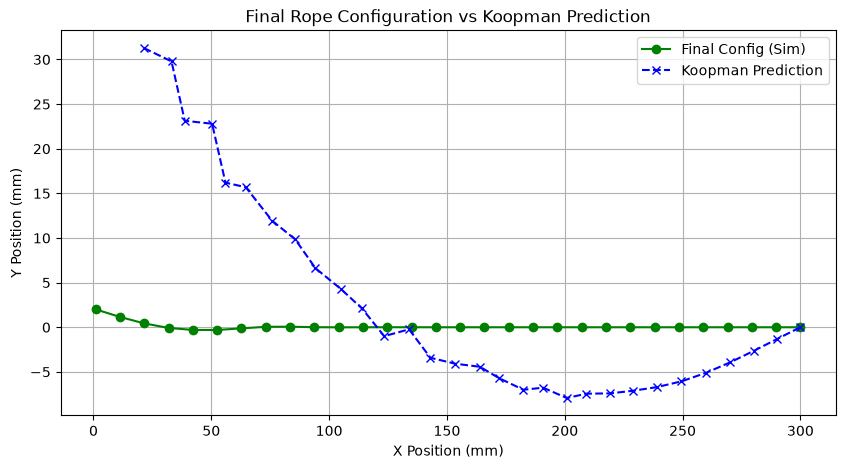

In [4]:
import numpy as np
import torch
from pathlib import Path

from ngk_simple import RopeKoopmanDataset, KoopmanModel
from mpc import load_exp_args  # just parses the "Args: {...}" line from the training log

# Applying the trained Koopman model to the current rope state.
#
# The checkpoint only holds state_dicts for the four submodules -- to load them you
# need a KoopmanModel built with the SAME dims the run was trained with (koopman_dim,
# hidden_dim, encoded_control_dim, ...), and the normalisation stats (state_mean,
# state_std, cmd_scale), which the training script never writes to disk. Both are
# recovered here: dims from the run's saved "Args: ..." log line, normalisation by
# re-fitting RopeKoopmanDataset on the same training CSVs.
results_dir = "training_results"
exp_name = "exp_simple_1788069999"
ckpt_dir = Path(results_dir) / "checkpoints" / exp_name
ta = load_exp_args(results_dir, exp_name)

dataset = RopeKoopmanDataset(
    ta["csv"], features=tuple(ta["features"]), horizon=1,
    normalize=not ta.get("no_normalize", False), clamp_tol_mm=None,
)


print("state_mean shape:", np.shape(dataset.state_mean))
print("state_std  shape:", np.shape(dataset.state_std))
print("cmd_scale:", dataset.cmd_scale)
print("pos_slice:", dataset.pos_slice, "feature pos:", dataset.feature_slices["pos"])
assert dataset.pos_slice == dataset.feature_slices["pos"]

# what does a real sample look like?
sample = dataset[0]
print("sample len:", len(sample), [tuple(s.shape) for s in sample])

# command magnitudes actually seen in training
cmds = np.asarray([dataset[i][1].numpy() for i in range(0, len(dataset), 97)])
print("|cmd| pct (50/90/99/max):", np.percentile(np.abs(cmds), [50,90,99,100], axis=0))

# denormalised state ranges -> tells you the units of the vel block
xs = (dataset[0][0].numpy() * dataset.state_std[0]) + dataset.state_mean[0]
print("pos range mm:", xs[dataset.feature_slices['pos']].min(), xs[dataset.feature_slices['pos']].max())
if "vel" in dataset.feature_slices:
    print("vel range   :", xs[dataset.feature_slices['vel']].min(), xs[dataset.feature_slices['vel']].max())
    

device = torch.device("cpu")
model = KoopmanModel(
    state_dim=dataset.state_dim,
    control_dim=dataset.control_dim,
    koopman_dim=ta["koopman_dim"],
    encoded_control_dim=ta.get("encoded_control_dim", 16),
    hidden_dim=ta["hidden_dim"],
    num_hidden=ta["num_hidden"],
    control_hidden_dim=ta.get("control_hidden_dim", 64),
    control_num_hidden=ta.get("control_num_hidden", 2),
    operator_bias=not ta.get("no_operator_bias", False),
).to(device)

ld = lambda f: torch.load(ckpt_dir / f, map_location=device)
model.encoder.load_state_dict(ld("koopman_enc.pt"))
model.decoder.load_state_dict(ld("koopman_dec.pt"))
model.operator.load_state_dict(ld("koopman_op.pt"))
#model.input_encoder.load_state_dict(ld("koopman_input_enc.pt"))
model.eval()
for p in model.parameters():
    p.requires_grad_(False)

A = model.operator.A.detach().numpy()
print("rho(A) =", np.max(np.abs(np.linalg.eigvals(A))))

mean = torch.as_tensor(dataset.state_mean[0])
std = torch.as_tensor(dataset.state_std[0])
pos_slice = dataset.pos_slice
n_nodes = (pos_slice.stop - pos_slice.start) // 2

# Pack the sim's CURRENT positions + velocities into the model's [pos, vel] state
# layout (node-major x,y within each block -- see RopeKoopmanDataset). Using just
# final_config.flatten() isn't enough: it's missing the velocity block the model
# was trained on (state_dim 120 = 60 pos + 60 vel), and it's not yet normalised.
state_0 = np.zeros(dataset.state_dim, dtype=np.float32)
state_0[dataset.feature_slices["pos"]] = env.get_positions(mm=True)[:, :2].reshape(-1)
if "vel" in dataset.feature_slices:
    state_0[dataset.feature_slices["vel"]] = env.get_velocities(mm=True)[:, :2].reshape(-1)
state_0 = torch.as_tensor(state_0).unsqueeze(0)

xn = (state_0 - mean) / std
print("normalised state |z|: max", xn.abs().max().item(), " mean", xn.abs().mean().item())

# applyinhg the same random input data to the Koopman model, to predict the next state
cmd_mm = torch.as_tensor(u[0], dtype=torch.float32).unsqueeze(0)  # shape (1, 2)

with torch.no_grad():
    rec = model.decoder(model.encoder(xn)) * std + mean
rec_pos = rec[0, dataset.pos_slice].reshape(n_nodes, 2).numpy()
print("recon RMSE (mm):", np.sqrt(((rec_pos - pos_before)**2).sum(1).mean()))

with torch.no_grad():
    z0 = model.encoder((state_0 - mean) / std)
    u_lifted = cmd_mm / dataset.cmd_scale
    z1 = model.operator(z0, u_lifted)
    state_1 = model.decoder(z1) * std + mean

pred_pos = state_1[0, pos_slice].reshape(n_nodes, 2).numpy()

print("1-step RMSE (mm):", np.sqrt(((pred_pos - final_config[:, :2])**2).sum(1).mean()))
print("node-0 err (mm):", np.linalg.norm(pred_pos[0] - final_config[0, :2]))

print("Koopman-predicted node positions after this command (mm):")
print(pred_pos[:5], "...")


# Plot the Koopman-predicted rope configuration with fixed size
#  and uniform axes, so the two plots can be compared visually.
plt.figure(figsize=(10, 5))
plt.plot(final_config[:, 0], final_config[:, 1], 'o-', color='g', label='Final Config (Sim)')
plt.plot(pred_pos[:, 0], pred_pos[:, 1], 'x--', color='b', label='Koopman Prediction')
plt.xlabel('X Position (mm)')
plt.ylabel('Y Position (mm)')
plt.title('Final Rope Configuration vs Koopman Prediction')
plt.legend()
plt.grid(True)
plt.show()



--- goal shape ---
segment len min/max: 10.345 / 10.345  (expect ~10.345)
goal anchor (node 29): [300.   0.]    sim anchor: [300.   0.]
goal node 0: [ 300. -300.]    sim node 0: [1. 2.]
tip travel required (mm): 425.0
goal |z|: max 3.666  mean 0.746   (training states sit at |z| <= ~1.0)
goal recon RMSE (mm): 9.919   max node err: 23.443 (node 0)
verdict: marginal -> inspect the plot


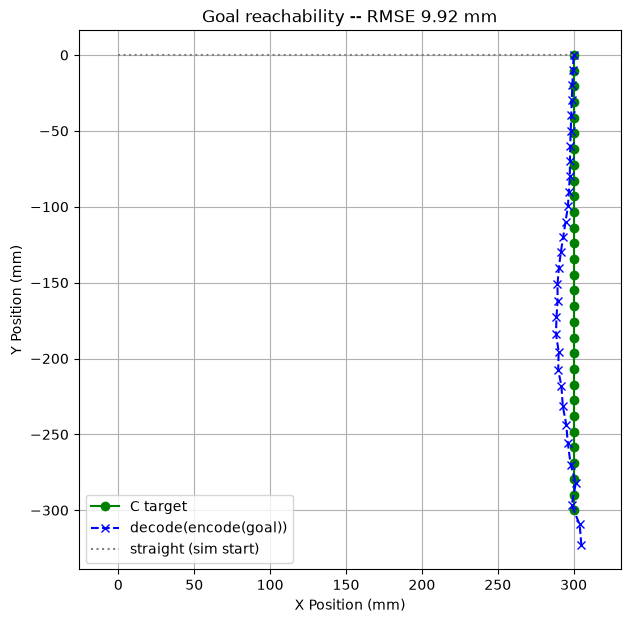

In [5]:


# ============================================================================
# GOAL-STATE REACHABILITY CHECK
# ----------------------------------------------------------------------------
# Everything above measures the model near the straight rope -- the regime it
# was trained in. This asks the separate question: can the autoencoder even
# REPRESENT the C-shape target? decode(encode(x_goal)) is an upper bound on how
# well any controller could ever track it. If this reconstruction is far from
# the goal, the target isn't in the latent space and no MPC cost weighting,
# horizon length, or A-matrix fix will recover it.
# ============================================================================
import json

shape_path = "rope_all_shapes/rope_I.json"   

J = json.load(open(shape_path))
goal = np.array(J["nodes"], dtype=np.float32)
assert goal.shape == (n_nodes, 2), f"JSON has {goal.shape[0]} nodes, model wants {n_nodes}"

# --- frame sanity: the JSON must live in the SAME frame as the sim ----------
# node 29 is the anchored end; it has to coincide with the sim's fixed node.
seg = np.linalg.norm(np.diff(goal, axis=0), axis=1)
print("\n--- goal shape ---")
print("segment len min/max: %.3f / %.3f  (expect ~%.3f)"
      % (seg.min(), seg.max(), J["rope_length"] / (n_nodes - 1)))
print("goal anchor (node %d):" % (n_nodes - 1), goal[-1],
      "   sim anchor:", env.get_positions(mm=True)[-1, :2])
print("goal node 0:", goal[0], "   sim node 0:", env.get_positions(mm=True)[0, :2])
print("tip travel required (mm): %.1f"
      % np.linalg.norm(goal[0] - env.get_positions(mm=True)[0, :2]))

# --- build the goal state: pos block filled, vel block ZERO (static target) --
x_goal = np.zeros(dataset.state_dim, dtype=np.float32)
x_goal[dataset.feature_slices["pos"]] = goal.reshape(-1)
xg = (torch.as_tensor(x_goal).unsqueeze(0) - mean) / std
print("goal |z|: max %.3f  mean %.3f   (training states sit at |z| <= ~1.0)"
      % (xg.abs().max().item(), xg.abs().mean().item()))

# --- the actual check -------------------------------------------------------
with torch.no_grad():
    rec_g = model.decoder(model.encoder(xg)) * std + mean
goal_rec = rec_g[0, pos_slice].reshape(n_nodes, 2).numpy()

per_node = np.linalg.norm(goal_rec - goal, axis=1)
goal_rmse = np.sqrt((per_node ** 2).mean())
print("goal recon RMSE (mm): %.3f   max node err: %.3f (node %d)"
      % (goal_rmse, per_node.max(), int(per_node.argmax())))
print("verdict:",
      "OK -> build the MPC" if goal_rmse < 2.0 else
      "marginal -> inspect the plot" if goal_rmse < 10.0 else
      "UNREACHABLE -> encoder coverage problem, needs curled training data")

plt.figure(figsize=(7, 7))
plt.plot(goal[:, 0], goal[:, 1], 'o-', color='g', label='C target')
plt.plot(goal_rec[:, 0], goal_rec[:, 1], 'x--', color='b', label='decode(encode(goal))')
plt.plot([0, 300], [0, 0], ':', color='gray', label='straight (sim start)')
plt.axis('equal')
plt.xlabel('X Position (mm)')
plt.ylabel('Y Position (mm)')
plt.title('Goal reachability -- RMSE %.2f mm' % goal_rmse)
plt.legend()
plt.grid(True)
plt.show()


=== I ===
anchor: JSON [300.   0.]  sim [300.   0.]
tip travel 424.3 mm over 473 steps, per-step 0.899 mm
reached seg len min/max: 10.345 / 10.345  (rest 10.345)
node-0 landed at: [ 300. -300.]  target: [ 300. -300.]
reached vs JSON target RMSE: 0.12 mm


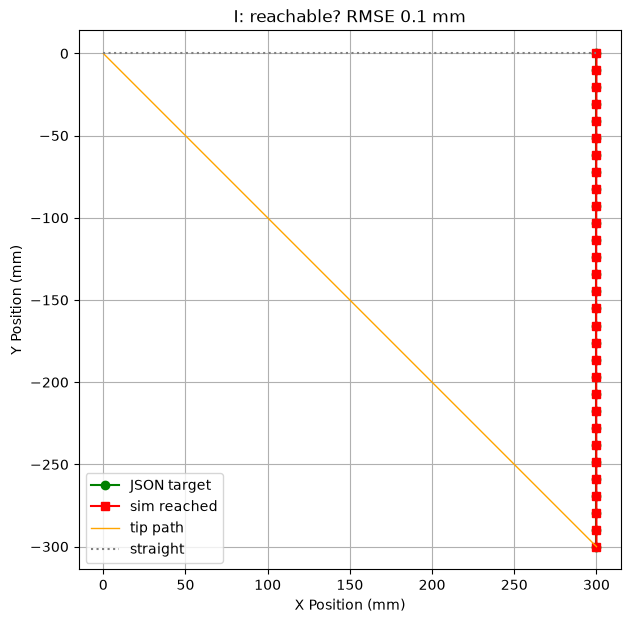

In [6]:
# Sim-based reachability check: can the ROD actually settle into each letter shape?
# A geometrically-drawn letter usually isn't an equilibrium of an elastic rod pinned
# at two nodes, so whatever the sim settles into is the honest MPC target.

import json
import numpy as np
import matplotlib.pyplot as plt

MM = 1000.0


STEP_MM = 0.9        # per-step tip motion (training range 0.02-1.5)
SETTLE = 500         # zero-command steps to let it come to rest

J = json.load(open(shape_path))
goal = np.array(J["nodes"], dtype=float)
name = J.get("shape", shape_path)

env.reset()                                        # always start from straight
p0 = env.get_positions(mm=True)[0, :2].copy()
target_n0 = goal[0]                                # drive node 0 to ITS target

dist = np.linalg.norm(target_n0 - p0)
n_steps = max(2, int(np.ceil(dist / STEP_MM)) + 1)
path = p0 + np.linspace(0, 1, n_steps)[:, None] * (target_n0 - p0)   # mm
step_mm = np.linalg.norm(np.diff(path, axis=0), axis=1)[0]

print(f"\n=== {name} ===")
print(f"anchor: JSON {goal[-1]}  sim {env.get_positions(mm=True)[-1, :2]}")
print(f"tip travel {dist:.1f} mm over {n_steps} steps, per-step {step_mm:.3f} mm")

for k in range(1, n_steps):
    env.drive_step((path[k] - path[k-1]) / MM)     # mm -> m

for _ in range(SETTLE):                            # settle
    env.drive_step(np.zeros(2))

shape_reached = env.get_positions(mm=True)[:, :2]

rest_seg = J["rope_length"] / (goal.shape[0] - 1)
seg = np.linalg.norm(np.diff(shape_reached, axis=0), axis=1)
strain = (seg.max() - rest_seg) / rest_seg
print(f"reached seg len min/max: {seg.min():.3f} / {seg.max():.3f}  (rest {rest_seg:.3f})"
        + ("   <-- STRETCHING, tip path is dragging it taut" if abs(strain) > 0.01 else ""))
print(f"node-0 landed at: {shape_reached[0]}  target: {target_n0}")

rmse = np.sqrt(((shape_reached - goal)**2).sum(1).mean())
print(f"reached vs JSON target RMSE: {rmse:.2f} mm")


plt.figure(figsize=(7, 7))
plt.plot(goal[:, 0], goal[:, 1], 'o-', color='g', label='JSON target')
plt.plot(shape_reached[:, 0], shape_reached[:, 1], 's-', color='r', label='sim reached')
plt.plot(path[:, 0], path[:, 1], '-', color='orange', lw=1, label='tip path')
plt.plot([0, J["rope_length"]], [0, 0], ':', color='gray', label='straight')
plt.axis('equal'); plt.grid(True); plt.legend()
plt.xlabel('X Position (mm)'); plt.ylabel('Y Position (mm)')
plt.title(f'{name}: reachable? RMSE {rmse:.1f} mm')
plt.show()